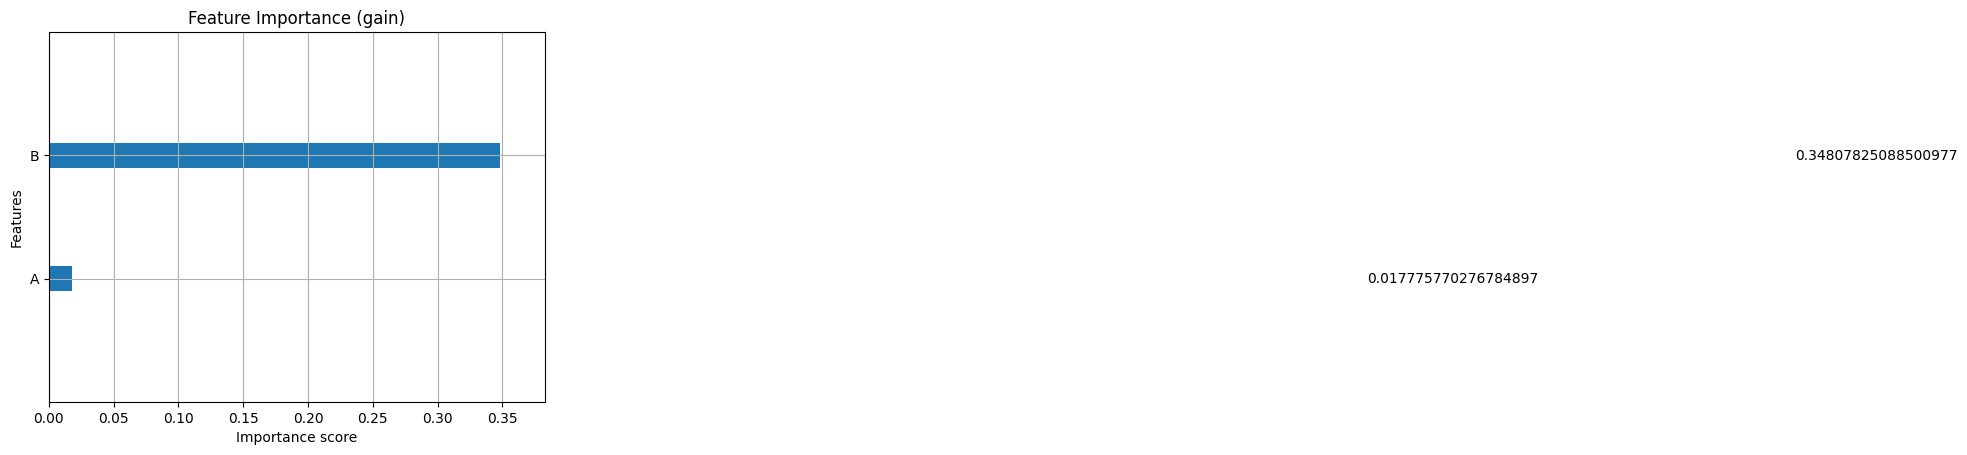

In [9]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

# Example data
X = pd.DataFrame({
    'A': range(10),
    'B': [2, 5, 3, 7, 1, 4, 8, 6, 9, 0],
    'C': [1, 3, 2, 4, 5, 0, 6, 7, 8, 9]
})
y = [5, 7, 6, 8, 5, 6, 9, 7, 10, 6]

# Train regressor
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
# By gain (how much a feature improves the model)
xgb.plot_importance(model, importance_type='gain')
plt.title("Feature Importance (gain)")
plt.show()



{'A': 0.017775770276784897, 'B': 0.34807825088500977}


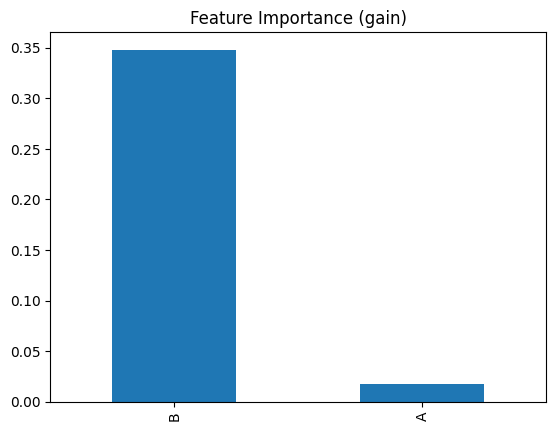

In [10]:
# Get feature importance as dict
importance_dict = model.get_booster().get_score(importance_type='gain')
print(importance_dict)

# Convert to Pandas Series for sorting & plotting
fi = pd.Series(importance_dict).sort_values(ascending=False)
fi.plot(kind='bar', title='Feature Importance (gain)')
plt.show()


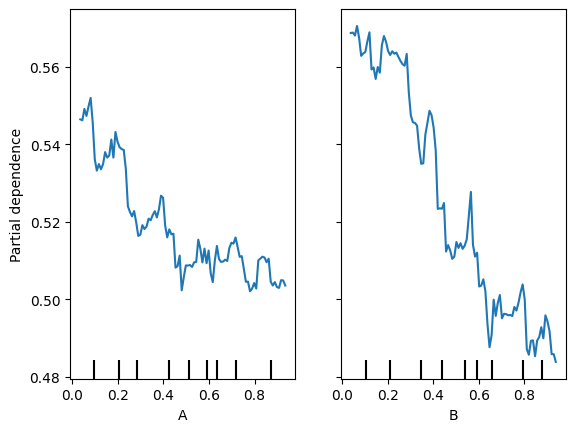

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import pandas as pd
import numpy as np

# Example data
X = pd.DataFrame(np.random.rand(100, 3), columns=['A','B','C'])
y = np.random.rand(100, 2)  # 2-output regression

# Train multi-output forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Partial dependence for first output (target=0)
PartialDependenceDisplay.from_estimator(
    rf,
    X,
    features=[0, 1],  # feature indices or names
    target=0  # choose which output
)


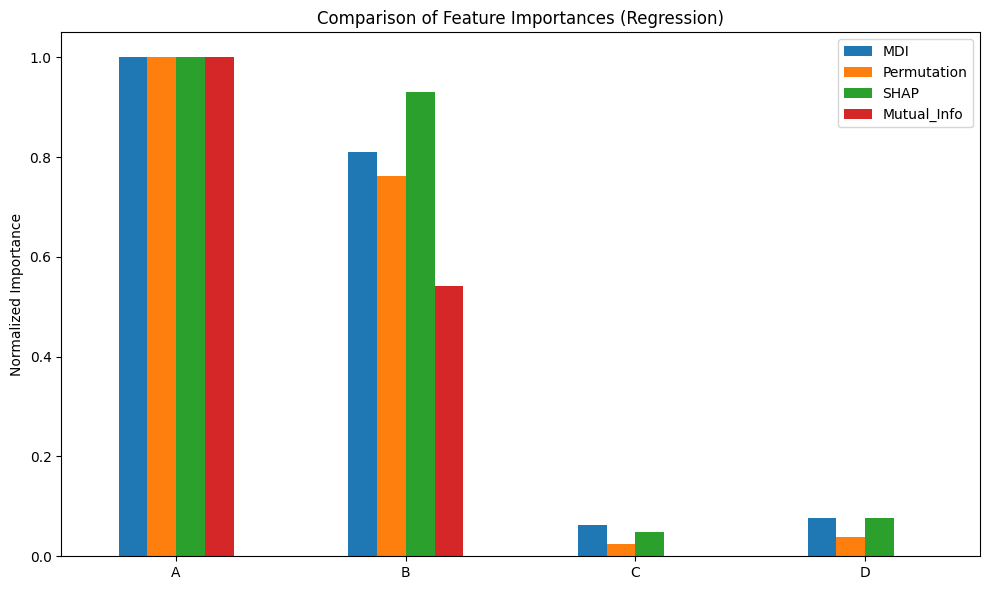

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
import shap

# ---------------------------
# Example Data
# ---------------------------
np.random.seed(42)
X = pd.DataFrame({
    'A': np.random.rand(100),
    'B': np.random.rand(100),
    'C': np.random.rand(100),
    'D': np.random.rand(100)
})
y = X['A'] * 2 + X['B'] * 2 + np.random.rand(100)  # target depends on A and B

# ---------------------------
# Train Random Forest
# ---------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# ---------------------------
# 1. Tree-based Feature Importance (MDI)
# ---------------------------
mdi_importances = pd.Series(rf.feature_importances_, index=X.columns)

# ---------------------------
# 2. Permutation Importance
# ---------------------------
perm_result = permutation_importance(rf, X, y, n_repeats=10, random_state=42)
perm_importances = pd.Series(perm_result.importances_mean, index=X.columns)

# ---------------------------
# 3. SHAP Values
# ---------------------------
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap_importances = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)

# ---------------------------
# 4. Mutual Information
# ---------------------------
mi_importances = pd.Series(mutual_info_regression(X, y, random_state=42), index=X.columns)

# ---------------------------
# Combine into DataFrame
# ---------------------------
all_importances = pd.DataFrame({
    'MDI': mdi_importances,
    'Permutation': perm_importances,
    'SHAP': shap_importances,
    'Mutual_Info': mi_importances
})

# Normalize for plotting
all_importances = all_importances / all_importances.max()

# ---------------------------
# Plot
# ---------------------------
all_importances.plot(kind='bar', figsize=(10,6))
plt.title('Comparison of Feature Importances (Regression)')
plt.ylabel('Normalized Importance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
